# Hidden-carry MNIST — clean run, fine-tuned per-channel encoder

`data.experiment=hidden_carry`, Residual SCBM (1 residual), no `L_int`, `corruption_strength=0`.
Encoder initialised from `backbones/carry_c0.0_s0_perchannel/encoder.pt` and fine-tuned
(`freeze_encoder=false`).

## The dataset

Four MNIST digit images stacked as channels, `[4, 28, 28]`. Ordered digit pairs are drawn
exactly uniformly (`_balanced_digit_pairs`: every one of the 100 pairs once per block of 100),
so all four (A, B) cells are equally populated by construction.

| | definition | role |
|---|---|---|
| `A`  | `1[d1 >= 5]` | observed concept, parent of X |
| `B`  | `1[d2 >= 5]` | observed concept, parent of X |
| `D1` | `1[d3 >= 5]` | observed concept, distractor |
| `D2` | `1[d4 >= 5]` | observed concept, distractor |
| `X`  | `1[d1 + d2 >= 10]` — the addition **carry** | **hidden**, oracle only, never in the bottleneck |
| `y`  | `4A + 2B + X` | 8 encodings, 6 reachable |

X is not a function of (A, B): when `A == B` the carry is determined (`A=B=0` → X=0,
`A=B=1` → X=1), but when `A != B` it genuinely depends on the digit values. So **the
`A != B` cells are the whole experiment** — that is the only place a model has to route
the carry through the residual rather than read it off the concepts.

Designed signature: `P(X)=0.45`, `corr(X, A) = corr(X, B) = +0.50`, `Cov(X, D1) = Cov(X, D2) = 0`.
The concept↔residual cross-block should therefore light up on A and B and stay flat on D1, D2.

Splits: 12 000 train / 2 400 val / 10 000 test.

In [32]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score

pd.set_option("display.width", 160)

In [33]:
RUN = Path(
    "experiments/scbm_residual/MNIST-Add-Cov/"
    "planted_xor_clean_perchannel_2026-09-11_12-34-13_seed_0_e6127"
)

# RUN = Path(
#     "experiments/scbm_residual/MNIST-Add-Cov/"
#     "planted_xor_MNIST_ADD_carry_clean_diagnostic_L_int_extension_loss_weight_1_2026-09-08_12-57-44_58d13"
# )



# [A, B, D1, D2] in bottleneck order, then the single residual dimension.
CHANNELS = ["A (d1>=5)", "B (d2>=5)", "D1 (d3>=5)", "D2 (d4>=5)", "res"]
SPLITS = ["train", "val", "test"]


def load(split):
    """Artifacts dumped by validate_one_epoch_scbm_residual for one split."""
    g = lambda name: torch.load(RUN / split / f"{name}.pt", map_location="cpu").numpy()
    d = {
        "c_res_mu": g("c_res_mu"),            # [N, 5] concept+residual logit means
        "c_true": g("c_true"),                # [N, 4]
        "y_true": g("y_true"),
        "y_pred": g("y_pred"),                # [N, 8] logits
        "probs": g("concepts_residuals_pred_probs_mean"),
        "cov": g("avg_covariance_matrix"),    # [5, 5], Sigma(x) averaged over the split
        "covs": g("covariance_matrices"),     # [N, 5, 5]
    }
    # y = 4A + 2B + X, so the oracle carry is just the low bit of the label.
    d["A"], d["B"], d["X"] = d["y_true"] // 4, (d["y_true"] // 2) % 2, d["y_true"] % 2
    pred = d["y_pred"].argmax(1)
    d["A_hat"], d["B_hat"], d["X_hat"] = pred // 4, (pred // 2) % 2, pred % 2
    d["pred"] = pred
    return d


data = {s: load(s) for s in SPLITS}
cfg = ast.literal_eval((RUN / "log.txt").read_text().splitlines()[0])
print({k: cfg["data"][k] for k in ["experiment", "num_concepts", "num_residuals",
                                   "num_classes", "corruption_strength"]})
print({k: cfg["model"][k] for k in ["encoder_arch", "cov_type", "reg_weight",
                                    "use_L_int_extension_loss"]})

{'experiment': 'hidden_carry', 'num_concepts': 4, 'num_residuals': 1, 'num_classes': 8, 'corruption_strength': 0.0}
{'encoder_arch': 'per_channel_mnist_encoder', 'cov_type': 'amortized', 'reg_weight': 0, 'use_L_int_extension_loss': False}


## Does the data match the design?

In [34]:
d = data["test"]
design = pd.DataFrame(
    {
        "corr(X, ·)": [np.corrcoef(d["X"], d["c_true"][:, j])[0, 1] for j in range(4)],
        "P(concept=1)": d["c_true"].mean(0),
    },
    index=CHANNELS[:4],
)
print(design.round(4))
print(f"\nP(X=1) = {d['X'].mean():.4f}")
print("\nP(X=1) per (A,B) cell — X is determined off the diagonal-free cells only:")
print(pd.DataFrame(
    [[f"{d['X'][(d['A'] == a) & (d['B'] == b)].mean():.3f}"
      f"  (n={((d['A'] == a) & (d['B'] == b)).sum()})" for b in (0, 1)] for a in (0, 1)],
    index=["A=0", "A=1"], columns=["B=0", "B=1"],
))

            corr(X, ·)  P(concept=1)
A (d1>=5)       0.5025           0.5
B (d2>=5)       0.5025           0.5
D1 (d3>=5)      0.0064           0.5
D2 (d4>=5)     -0.0076           0.5

P(X=1) = 0.4500

P(X=1) per (A,B) cell — X is determined off the diagonal-free cells only:
                 B=0              B=1
A=0  0.000  (n=2500)  0.400  (n=2500)
A=1  0.400  (n=2500)  1.000  (n=2500)


## Model performance

`bit X` is the interesting column: it is the part of the label the concepts cannot supply.
`X | A!=B` restricts to the cells where the carry is genuinely hidden — the other two cells
are readable straight off A and B.

In [35]:
def _reachable_probs(d):
    probs = torch.softmax(torch.tensor(d["y_pred"]), 1).numpy()
    probs = probs[:, np.unique(d["y_true"])]
    return probs / probs.sum(1, keepdims=True)


rows = []
for s in SPLITS:
    d = data[s]
    off = d["A"] != d["B"]          # cells where X is NOT determined by (A, B)
    on = ~off
    # Best achievable on X using (A, B) alone: predict the per-cell majority.
    ceiling = sum(
        m.mean() * max(d["X"][m].mean(), 1 - d["X"][m].mean())
        for a in (0, 1) for b in (0, 1)
        for m in [(d["A"] == a) & (d["B"] == b)]
    )
    rows.append({
        "n": len(d["y_true"]),
        "y acc": (d["pred"] == d["y_true"]).mean(),
        # Only 6 of the 8 label encodings are reachable (A==B forces X), so the
        # unreachable head columns are dropped and the rest renormalised.
        "y AUROC (ovr)": roc_auc_score(
            d["y_true"], _reachable_probs(d), multi_class="ovr", average="macro",
            labels=np.unique(d["y_true"]),
        ),
        "bit A": (d["A_hat"] == d["A"]).mean(),
        "bit B": (d["B_hat"] == d["B"]).mean(),
        "bit X": (d["X_hat"] == d["X"]).mean(),
        "X | A==B": (d["X_hat"][on] == d["X"][on]).mean(),
        "X | A!=B": (d["X_hat"][off] == d["X"][off]).mean(),
        "X ceiling from (A,B)": ceiling,
        "concept acc": ((d["probs"][:, :4] > 0.5) == d["c_true"]).mean(),
        "concept AUROC": np.mean([roc_auc_score(d["c_true"][:, j], d["probs"][:, j])
                                  for j in range(4)]),
    })
print(pd.DataFrame(rows, index=SPLITS).round(4).T)

                           train        val        test
n                     12000.0000  2400.0000  10000.0000
y acc                     0.8000     0.7850      0.7803
y AUROC (ovr)             0.9521     0.9436      0.9428
bit A                     1.0000     0.9896      0.9853
bit B                     1.0000     0.9883      0.9886
bit X                     0.8000     0.7954      0.7935
X | A==B                  1.0000     0.9875      0.9856
X | A!=B                  0.6000     0.6033      0.6014
X ceiling from (A,B)      0.8000     0.8000      0.8000
concept acc               1.0000     0.9868      0.9880
concept AUROC             1.0000     0.9987      0.9987


## Is the carry in the residual?

AUC of the residual mean `mu_r(x)` against the oracle carry, split by whether (A, B)
already determines it.

In [36]:
rows = []
for s in SPLITS:
    d = data[s]
    r, off = d["c_res_mu"][:, 4], d["A"] != d["B"]
    rows.append({
        "AUC(res_mu -> X)": roc_auc_score(d["X"], r),
        "AUC | A==B (X determined)": roc_auc_score(d["X"][~off], r[~off]),
        "AUC | A!=B (X hidden)": roc_auc_score(d["X"][off], r[off]),
    })
print(pd.DataFrame(rows, index=SPLITS).round(4).T)

                            train     val    test
AUC(res_mu -> X)           0.7371  0.7274  0.7363
AUC | A==B (X determined)  1.0000  0.9981  0.9980
AUC | A!=B (X hidden)      0.4710  0.4657  0.4689


## Covariance and correlation of the concept–residual channel

`avg_covariance_matrix.pt` is `Sigma(x)` averaged over the split; the amortised covariance is
per-sample, so the mean of the per-sample correlations is reported alongside it (they are not
the same object — the first correlates an averaged covariance, the second averages correlations).

In [37]:
d = data["test"]
cov = pd.DataFrame(d["cov"], index=CHANNELS, columns=CHANNELS)
print("Average covariance, test split\n")
print(cov.round(4))

sd = np.sqrt(np.diag(d["cov"]))
corr_of_avg = pd.DataFrame(d["cov"] / np.outer(sd, sd), index=CHANNELS, columns=CHANNELS)
print("\n\nCorrelation of the average covariance\n")
print(corr_of_avg.round(4))

s = np.sqrt(np.einsum("nii->ni", d["covs"]))
per_sample_corr = d["covs"] / (s[:, :, None] * s[:, None, :])
corr_mean = pd.DataFrame(per_sample_corr.mean(0), index=CHANNELS, columns=CHANNELS)
print("\n\nMean of per-sample correlations\n")
print(corr_mean.round(4))
print("\nsd across samples of the residual row:",
      np.round(per_sample_corr.std(0)[4], 4))

Average covariance, test split

            A (d1>=5)  B (d2>=5)  D1 (d3>=5)  D2 (d4>=5)     res
A (d1>=5)      0.0299    -0.0008     -0.0110      0.0096 -0.0094
B (d2>=5)     -0.0008     0.0579      0.0098      0.0077 -0.0031
D1 (d3>=5)    -0.0110     0.0098      0.1071      0.0246 -0.0403
D2 (d4>=5)     0.0096     0.0077      0.0246      0.1185 -0.0237
res           -0.0094    -0.0031     -0.0403     -0.0237  0.8734


Correlation of the average covariance

            A (d1>=5)  B (d2>=5)  D1 (d3>=5)  D2 (d4>=5)     res
A (d1>=5)      1.0000    -0.0180     -0.1951      0.1613 -0.0580
B (d2>=5)     -0.0180     1.0000      0.1239      0.0932 -0.0137
D1 (d3>=5)    -0.1951     0.1239      1.0000      0.2185 -0.1317
D2 (d4>=5)     0.1613     0.0932      0.2185      1.0000 -0.0736
res           -0.0580    -0.0137     -0.1317     -0.0736  1.0000


Mean of per-sample correlations

            A (d1>=5)  B (d2>=5)  D1 (d3>=5)  D2 (d4>=5)     res
A (d1>=5)      1.0000     0.2284     -0.0486   

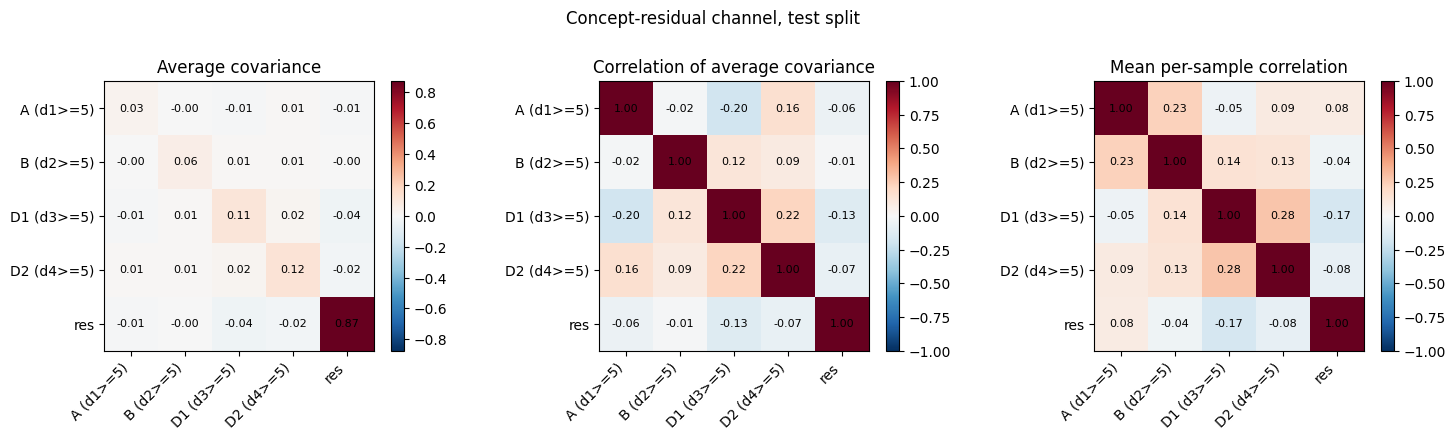

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
panels = [
    (cov, "Average covariance", None),
    (corr_of_avg, "Correlation of average covariance", 1.0),
    (corr_mean, "Mean per-sample correlation", 1.0),
]
for ax, (m, title, lim) in zip(axes, panels):
    v = lim if lim is not None else np.abs(m.values).max()
    im = ax.imshow(m.values, cmap="RdBu_r", vmin=-v, vmax=v)
    ax.set_xticks(range(len(CHANNELS)), CHANNELS, rotation=45, ha="right")
    ax.set_yticks(range(len(CHANNELS)), CHANNELS)
    ax.set_title(title)
    for i in range(len(CHANNELS)):
        for j in range(len(CHANNELS)):
            ax.text(j, i, f"{m.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Concept-residual channel, test split", y=1.02)
fig.tight_layout()
plt.show()

## Correlation of `c_res_mu` itself

The three panels above are all built from `Sigma(x)`, the *conditional* covariance of
`eta | x` — the width of the Gaussian the model samples from at a fixed input. That is a
different object from the correlation of the channel **across samples**, which is what says
what each dimension encodes. In this run the two are not comparable in size: the across-sample
variance of the means is ~700-1400 per dimension against a conditional variance of 0.03-0.87,
so `Sigma(x)` is a noise floor three to four orders of magnitude below the signal (`reg_weight=0`
leaves nothing bounding the logit scale, and the encoder pushed the logits to sd ~27-37 —
98% of concept probabilities are outside [0.01, 0.99]).

`corrcoef(c_res_mu)` is the panel that answers "what is the residual encoding".

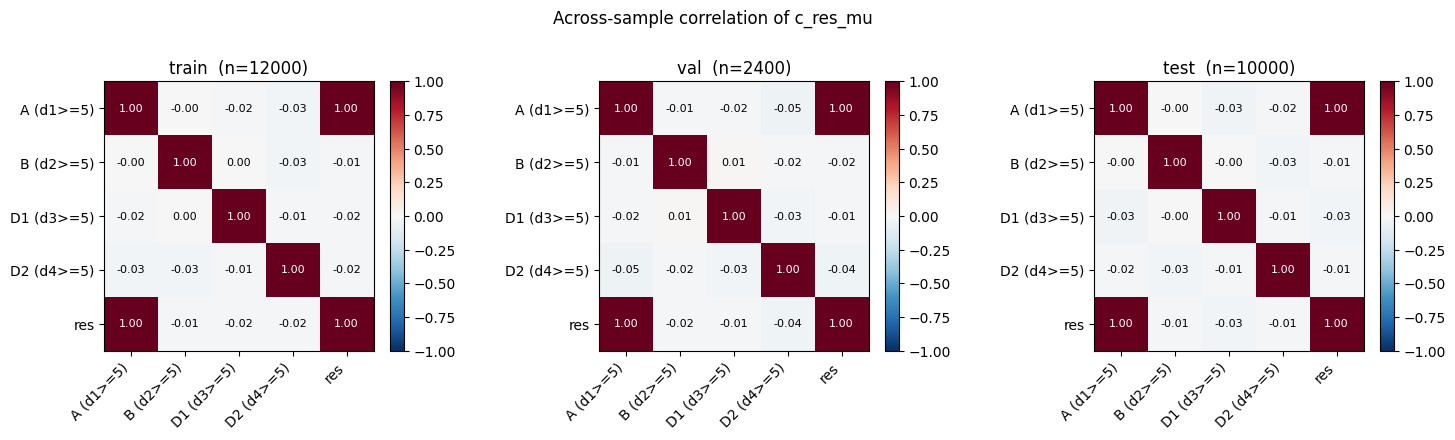

Across-sample correlation, test split

            A (d1>=5)  B (d2>=5)  D1 (d3>=5)  D2 (d4>=5)     res
A (d1>=5)      1.0000    -0.0042     -0.0337     -0.0203  0.9997
B (d2>=5)     -0.0042     1.0000     -0.0033     -0.0289 -0.0109
D1 (d3>=5)    -0.0337    -0.0033      1.0000     -0.0124 -0.0285
D2 (d4>=5)    -0.0203    -0.0289     -0.0124      1.0000 -0.0103
res            0.9997    -0.0109     -0.0285     -0.0103  1.0000


Var across samples of mu (signal) vs mean diag Sigma(x) (noise), test

              Var_n[mu]  mean diag Sigma(x)           SNR
A (d1>=5)    704.804016               0.030  23555.619141
B (d2>=5)    893.630005               0.058  15429.497070
D1 (d3>=5)   733.625977               0.107   6852.583984
D2 (d4>=5)   665.244019               0.118   5614.978027
res         1390.083984               0.873   1591.560059


res_mu = -0.553 + 1.4045*mu_A + -0.0080*mu_B + 0.0073*mu_D1 + 0.0142*mu_D2
R2(res_mu ~ c_mu) = 0.9996   |   leftover sd 0.753 against channel sd 37.

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, s in zip(axes, SPLITS):
    C = np.corrcoef(data[s]["c_res_mu"], rowvar=False)
    im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(CHANNELS)), CHANNELS, rotation=45, ha="right")
    ax.set_yticks(range(len(CHANNELS)), CHANNELS)
    ax.set_title(f"{s}  (n={len(data[s]['c_res_mu'])})")
    for i in range(len(CHANNELS)):
        for j in range(len(CHANNELS)):
            ax.text(j, i, f"{C[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(C[i, j]) > 0.6 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Across-sample correlation of c_res_mu", y=1.02)
fig.tight_layout()
plt.show()

d = data["test"]
print("Across-sample correlation, test split\n")
print(pd.DataFrame(np.corrcoef(d["c_res_mu"], rowvar=False),
                   index=CHANNELS, columns=CHANNELS).round(4))

# Scale check: Sigma(x) is a noise floor, not channel content.
print("\n\nVar across samples of mu (signal) vs mean diag Sigma(x) (noise), test\n")
print(pd.DataFrame({"Var_n[mu]": d["c_res_mu"].var(0),
                    "mean diag Sigma(x)": np.diag(d["cov"]),
                    "SNR": d["c_res_mu"].var(0) / np.diag(d["cov"])},
                   index=CHANNELS).round(3))

# The same panel as a regression: how much of res_mu is a linear function of c_mu.
r = d["c_res_mu"][:, 4]
Z = np.c_[np.ones(len(r)), d["c_res_mu"][:, :4]]
beta = np.linalg.lstsq(Z, r, rcond=None)[0]
cleaned = r - Z @ beta
print("\n\nres_mu = " + f"{beta[0]:.3f} + "
      + " + ".join(f"{b:.4f}*mu_{n.split()[0]}" for b, n in zip(beta[1:], CHANNELS[:4])))
print(f"R2(res_mu ~ c_mu) = {1 - cleaned.var() / r.var():.4f}"
      f"   |   leftover sd {cleaned.std():.3f} against channel sd {r.std():.2f}")
off = d["A"] != d["B"]
print(f"AUC(cleaned res_mu -> X | A!=B) = {roc_auc_score(d['X'][off], cleaned[off]):.4f}")

## Reading

The run reproduces the `(A, B)`-only ceiling and nothing beyond it: `y` accuracy 0.780 on test
against a ceiling of 0.800 for a model that predicts A and B perfectly and guesses the carry
by the per-cell majority. In the two cells where the carry is genuinely hidden (`A != B`) the
model sits at 0.60 — exactly the majority rate — and the residual's AUC against the carry
there is 0.469, i.e. chance. The apparent 0.736 overall AUC is entirely the `A == B` cells,
where X is a deterministic function of the concepts.

The cross-block matches that: the residual's correlation with A (-0.058) and B (-0.014) is
*smaller* than with the distractors D1 (-0.132) and D2 (-0.074), the opposite of the designed
signature, and the per-sample sd (~0.4) says the sign is not stable sample to sample. The
residual's conditional variance (0.87) dwarfs the concepts' (0.03-0.12) — it is carrying
noise, not the carry.

Note `reg_weight=0` and `use_L_int_extension_loss=false` in this run, so nothing was pushing
information into the residual.

## Is X still in the encoder?

The residual is at chance on the `A != B` cells, which leaves two very different
explanations: either the encoder never got the carry through the pixels into its feature
vector, or it did and the bottleneck threw it away. This separates them.

The encoder is lifted straight out of `model_best.pth` — the same fine-tuned weights that
produced the numbers above — held frozen in `eval()` mode, and a linear head is trained on
its 128-d features against the oracle carry X. `experiments/backbones/.../encoder.pt`, the
initialisation this run was fine-tuned *from*, is probed the same way, so the fine-tune's
own effect on X is visible as a difference between two rows rather than being asserted.

Two bars to read against:

* **overall** — the `(A, B)` ceiling (accuracy 0.80, AUROC 0.879). Anything at or below this
  is explained by the observed concepts alone.
* **`A != B`** — the cells where X is genuinely hidden. `P(X=1) = 0.4` in *both* of them, so
  `(A, B)` gives no ranking at all there and the ceiling is exactly **AUROC 0.5**. This is
  the column that matters; the overall AUROC is inflated by the `A == B` cells where X is a
  deterministic function of the concepts.

An MLP probe on the identical features is reported next to each linear one: the two together
separate "the information is gone" from "the information is there but not along a linear
direction". Read either as *recoverability*, not as a claim that the encoder represents X.

In [39]:
from types import SimpleNamespace

from torch.utils.data import DataLoader

from datasets.MNIST_add_cov_dataset import get_MNIST_add_cov_datasets
from models.models import PerChannelMNISTEncoder
from utils.utils import reset_random_seeds
# Imported, not restated: same overlay of the run's recorded config, same
# concept-only ceiling, same device choice as Test 1.
from encoder_capacity_check import build_config, concept_only_ceiling, pick_device

CKPT = RUN / "model_best.pth"        # the checkpoint the reported test numbers came from
FEATURE_DIM = 128                    # PerChannelMNISTEncoder output in this run

# Rebuild the exact data the run saw: every data/model key from its log.txt,
# only data_path swapped for the local one.
args = SimpleNamespace(run=RUN.name, corruption_strength=None, num_covariates=None,
                       epochs=None, seed=None)
config = build_config(args)
reset_random_seeds(config.seed)
torch.use_deterministic_algorithms(False)
device = pick_device()

trainset, valset, testset = get_MNIST_add_cov_datasets(
    config.data, config.incomplete, seed=config.seed
)
in_channels = int(config.data.num_covariates)


def encoder_from_scbm(path):
    """The fine-tuned encoder, lifted out of the full SCBM_residual state dict."""
    sd = torch.load(path, map_location="cpu")
    enc_sd = {k[len("encoder."):]: v for k, v in sd.items() if k.startswith("encoder.")}
    enc = PerChannelMNISTEncoder(in_channels=in_channels, output_dim=FEATURE_DIM)
    enc.load_state_dict(enc_sd)
    return enc.to(device)


def encoder_from_backbone(cluster_path):
    """The pretrained initialisation, i.e. the encoder BEFORE the SCBM fine-tune."""
    local = Path("experiments/backbones") / Path(cluster_path).parent.name / "encoder.pt"
    if not local.exists():
        return None, local
    enc = PerChannelMNISTEncoder(in_channels=in_channels, output_dim=FEATURE_DIM)
    enc.load_state_dict(torch.load(local, map_location="cpu"))
    return enc.to(device), local


@torch.no_grad()
def features_and_meta(encoder, dataset, batch_size=512):
    """Frozen forward pass. eval() so BatchNorm uses its running stats and dropout is off."""
    encoder.eval()
    H, meta = [], {"X": [], "concepts": [], "digits": []}
    for batch in DataLoader(dataset, batch_size=batch_size, shuffle=False):
        H.append(encoder(batch["features"].to(device)).cpu())
        meta["X"].append(batch["X"])
        meta["concepts"].append(batch["concepts"])
        meta["digits"].append(batch["digit_labels"])
    return (torch.cat(H).numpy(),
            {k: torch.cat(v).numpy() for k, v in meta.items()})


finetuned = encoder_from_scbm(CKPT)
pretrained, backbone_path = encoder_from_backbone(config.model.pretrained_encoder_path)

SETS = {"train": trainset, "val": valset, "test": testset}
feats = {"fine-tuned": {s: features_and_meta(finetuned, d) for s, d in SETS.items()}}
if pretrained is not None:
    feats["pretrained init"] = {s: features_and_meta(pretrained, d) for s, d in SETS.items()}

# Ceilings on the test split: the best any predictor can do from (A, B) alone.
extract_X = lambda batch: batch["X"]
ceil_acc, ceil_auroc = concept_only_ceiling(testset, extract_X, config.workers)

print(f"checkpoint      : {CKPT}")
print(f"backbone        : {backbone_path}"
      f"{'' if pretrained is not None else '   (missing - fine-tuned only)'}")
print(f"encoder         : PerChannelMNISTEncoder({in_channels} -> {FEATURE_DIM}), "
      f"{sum(p.numel() for p in finetuned.parameters()):,} params, frozen + eval")
print(f"features        : " + "  ".join(
    f"{s} {feats['fine-tuned'][s][0].shape}" for s in SETS))
print(f"corruption      : {config.data.corruption} @ {config.data.corruption_strength}")
print(f"\nconcept-only ceiling on X (test): accuracy {ceil_acc:.4f}, AUROC {ceil_auroc:.4f}")
print("On the A != B cells the ceiling is exactly AUROC 0.5 — P(X=1) is 0.4 in both, "
      "so (A, B) supplies no ranking there at all.")

hyperparameters from: planted_xor_clean_perchannel_2026-09-11_12-34-13_seed_0_e6127
MNIST-Add-Cov split fingerprints (data seed=0, experiment=hidden_carry, planted_function=xor):
  train n=12000  sha256[:16]=74693535e442fab4
  val   n=2400   sha256[:16]=3984fef0d7b3f1b4
  test  n=10000  sha256[:16]=a6185bf6f4d20fe9
  concepts exposed: ['A::digit1_ge_5', 'B::digit2_ge_5', 'D1::digit3_ge_5', 'D2::digit4_ge_5']
  Matching fingerprints => identical train/val/test samples across machines (independent of which concepts are exposed).
checkpoint      : experiments/scbm_residual/MNIST-Add-Cov/planted_xor_clean_perchannel_2026-09-11_12-34-13_seed_0_e6127/model_best.pth
backbone        : experiments/backbones/carry_c0.0_s0_perchannel/encoder.pt
encoder         : PerChannelMNISTEncoder(4 -> 128), 134,048 params, frozen + eval
features        : train (12000, 128)  val (2400, 128)  test (10000, 128)
corruption      : gaussian @ 0.0

concept-only ceiling on X (test): accuracy 0.8000, AUROC 0.8788
On 

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]


def fit_probe(Z, t, kind="linear", seed=0):
    """Fit on train, pick the regulariser on val, score on test. Z/t are dicts by split."""
    scaler = StandardScaler().fit(Z["train"])
    S = {s: scaler.transform(Z[s]) for s in Z}

    if kind == "linear":
        best = None
        for C in C_GRID:
            clf = LogisticRegression(C=C, max_iter=5000).fit(S["train"], t["train"])
            va = roc_auc_score(t["val"], clf.decision_function(S["val"]))
            if best is None or va > best[0]:
                best = (va, clf)
        clf = best[1]
        score = clf.decision_function(S["test"])
    else:
        clf = MLPClassifier(hidden_layer_sizes=(256,), max_iter=1000,
                            early_stopping=True, random_state=seed).fit(S["train"], t["train"])
        score = clf.predict_proba(S["test"])[:, 1]
    return clf.predict(S["test"]), score


def x_row(name, Z, t, A, B, kind="linear"):
    """One row of the X table: overall, and on the cells where (A, B) cannot help."""
    pred, score = fit_probe(Z, t, kind=kind)
    y, off = t["test"], A["test"] != B["test"]
    return {
        "probe": name,
        "acc": (pred == y).mean(),
        "AUROC": roc_auc_score(y, score),
        "acc | A!=B": (pred[off] == y[off]).mean(),
        "AUROC | A!=B": roc_auc_score(y[off], score[off]),
    }


# ---- encoder features -------------------------------------------------------
rows = []
for enc_name, per_split in feats.items():
    Z = {s: per_split[s][0] for s in SETS}
    t = {s: per_split[s][1]["X"].astype(int) for s in SETS}
    A = {s: per_split[s][1]["concepts"][:, 0].astype(int) for s in SETS}
    B = {s: per_split[s][1]["concepts"][:, 1].astype(int) for s in SETS}
    for kind in ("linear", "MLP"):
        rows.append(x_row(f"encoder {enc_name} (128d), {kind}", Z, t, A, B, kind=kind))

# ---- the bottleneck the model actually uses, from the saved artifacts --------
# Self-contained: c_res_mu and its X/A/B all come from the same dumped tensors,
# so row order is consistent without re-running a loader.
Zb = {s: data[s]["c_res_mu"] for s in SPLITS}
tb = {s: data[s]["X"].astype(int) for s in SPLITS}
Ab = {s: data[s]["A"].astype(int) for s in SPLITS}
Bb = {s: data[s]["B"].astype(int) for s in SPLITS}
rows.append(x_row("bottleneck c_res_mu (4c+1res), linear", Zb, tb, Ab, Bb))
rows.append(x_row("residual res_mu alone (1d), linear",
                  {s: Zb[s][:, 4:5] for s in SPLITS}, tb, Ab, Bb))

off_te = Ab["test"] != Bb["test"]
rows.append({"probe": "(A, B) ceiling", "acc": ceil_acc, "AUROC": ceil_auroc,
             "acc | A!=B": max(tb["test"][off_te].mean(), 1 - tb["test"][off_te].mean()),
             "AUROC | A!=B": 0.5})

print("Recovering the hidden carry X (test split)\n")
print(pd.DataFrame(rows).set_index("probe").round(4))

# ---- controls: what the same features do carry ------------------------------
ctrl = []
enc_feats = feats["fine-tuned"]
Z = {s: enc_feats[s][0] for s in SETS}
for j, name in enumerate(CHANNELS[:4]):
    t = {s: enc_feats[s][1]["concepts"][:, j].astype(int) for s in SETS}
    pred, score = fit_probe(Z, t)
    ctrl.append({"target": name, "acc": (pred == t["test"]).mean(),
                 "AUROC": roc_auc_score(t["test"], score)})

# Digit identity: the carry is 1[d1 + d2 >= 10], so this is the raw material for it.
for k in (0, 1):
    t = {s: enc_feats[s][1]["digits"][:, k] for s in SETS}
    scaler = StandardScaler().fit(Z["train"])
    clf = LogisticRegression(max_iter=5000).fit(scaler.transform(Z["train"]), t["train"])
    pred = clf.predict(scaler.transform(Z["test"]))
    ctrl.append({"target": f"digit d{k + 1} (10-way)", "acc": (pred == t["test"]).mean(),
                 "AUROC": np.nan})

print("\n\nControls — linear probes on the same fine-tuned features\n")
print(pd.DataFrame(ctrl).set_index("target").round(4))

Recovering the hidden carry X (test split)

                                           acc   AUROC  acc | A!=B  AUROC | A!=B
probe                                                                           
encoder fine-tuned (128d), linear       0.8874  0.9596      0.7940        0.8668
encoder fine-tuned (128d), MLP          0.9204  0.9776      0.8512        0.9227
encoder pretrained init (128d), linear  0.9077  0.9713      0.8446        0.9211
encoder pretrained init (128d), MLP     0.9784  0.9965      0.9686        0.9925
bottleneck c_res_mu (4c+1res), linear   0.7563  0.8573      0.5162        0.4265
residual res_mu alone (1d), linear      0.7393  0.7363      0.5092        0.4689
(A, B) ceiling                          0.8000  0.8788      0.6000        0.5000


Controls — linear probes on the same fine-tuned features

                      acc   AUROC
target                           
A (d1>=5)          0.9847  0.9980
B (d2>=5)          0.9876  0.9990
D1 (d3>=5)         0.9871  0.99

### Reading

The information is in the encoder. On the `A != B` cells, where `(A, B)` supplies nothing and
the ceiling is 0.5, a linear head on the fine-tuned features reaches **0.867 AUROC** and an
MLP **0.923** — while the bottleneck the model actually uses sits at 0.43 (`c_res_mu`) and
0.47 (the residual alone), i.e. chance. The carry survives the encoder and dies at the
bottleneck.

So the flat residual in this run is not an encoder-capacity failure. The features the concept
and residual heads read from are linearly carrying the carry at 0.87 AUROC; the single
residual dimension picks up none of it. With `reg_weight=0` and no `L_int`, nothing in the
objective asked it to — the head is free to solve `y` to the `(A, B)` ceiling and let the
residual carry noise, and that is what it did.

The fine-tune does *degrade* X, it just does not erase it: the pretrained initialisation
probes at 0.921 linear / 0.993 MLP on the same cells, so SCBM training cost about 0.05 AUROC
linearly and 0.07 non-linearly. The controls say why the loss is partial rather than total —
A, B, D1, D2 are all still at ~0.999 AUROC and the raw digit identities at ~94% 10-way
accuracy, and the carry is a threshold on `d1 + d2`, so it cannot be removed without damaging
the digit reading the concepts depend on.

The gap between the linear and MLP probes (0.867 vs 0.923 fine-tuned) also means part of what
remains is not linearly available — worth remembering, since the residual head is linear in
these features.